# TP Python 3 : Géotraitement vectoriel & régressions

**Géoinformatique II — Université de Lausanne**

---

Ce TP Python est le pendant numérique du **TP QGIS 3**. Tu vas reproduire les mêmes opérations de géotraitement vectoriel en Python, puis appliquer des modèles de régression sur les résultats.

| Partie | Bibliothèque | Ce que tu apprendras |
|--------|-------------|----------------------|
| **1. Sélection & extraction** | `geopandas` | Sélectionner des entités par attribut, dissoudre, découper |
| **2. Zones tampons** | `geopandas` / `shapely` | Créer des buffers, définir la zone urbaine (ZDB, ZU) |
| **3. Superposition** | `geopandas` / `shapely` | Union, différence, intersection → WUI |
| **4. Du vecteur au raster** | `rasterio` | Rasteriser des couches vectorielles |
| **5. Régressions** | `scikit-learn` | Régression logistique et linéaire sur données spatiales |

> 🔗 **Lien avec le TP QGIS 3** : tu vas recréer en Python le même résultat que dans QGIS —
> la **zone d'interface habitat-forêt (WUI)** du district bernois de _Frutigen-Niedersimmental_.


In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from rasterio.features import rasterize

from scipy.ndimage import distance_transform_edt

import geopandas as gpd

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, mean_absolute_error, r2_score)


In [54]:
# -------------------------------------------------------
# Chargement des données vectorielles depuis tp3.gpkg
# -------------------------------------------------------
GPKG_PATH = "tp3.gpkg"
CRS_REF   = 'EPSG:21781'   # CH1903 / LV03

foret     = gpd.read_file(GPKG_PATH, layer='Foret').to_crs(CRS_REF)
buildings = gpd.read_file(GPKG_PATH, layer='Buildings').to_crs(CRS_REF)
roads     = gpd.read_file(GPKG_PATH, layer='Roads').to_crs(CRS_REF)
communes  = gpd.read_file(GPKG_PATH, layer='Communes').to_crs(CRS_REF)
districts = gpd.read_file(GPKG_PATH, layer='Districts').to_crs(CRS_REF)

print("Couches vectorielles chargées depuis tp3.gpkg :")
for name, gdf in [
    ('Foret',     foret),
    ('Buildings', buildings),
    ('Roads',     roads),
    ('Communes',  communes),
    ('Districts', districts),
]:
    geom_type = gdf.geometry.geom_type.iloc[0]
    print(f"  {name:12s}: {len(gdf):7d} entités | CRS: EPSG:{gdf.crs.to_epsg()} | géométrie: {geom_type}")


Couches vectorielles chargées depuis tp3.gpkg :
  Foret       :   13461 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Buildings   :  373399 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Roads       :  112567 entités | CRS: EPSG:21781 | géométrie: MultiLineString
  Communes    :    8868 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Districts   :     233 entités | CRS: EPSG:21781 | géométrie: MultiPolygon


---
## Partie 1 — Sélection et extraction

Dans le TP QGIS 3, nous avons commencé par sélectionner les districts bernois de
_Frutigen-Niedersimmental_ et _Obersimmental-Saanen_, les avons fusionnés pour
définir le périmètre d'étude, puis avons découpé les autres couches dans ce périmètre.

En Python avec **geopandas**, les équivalents sont :

| Outil QGIS | Équivalent Python |
|---|---|
| Sélection par expression | `gdf[gdf['col'].str.contains(...)]` |
| Fusionner les entités | `gdf.dissolve()` |
| Couper (*Clip*) | `gpd.clip(layer, mask)` |

### 1.1 Sélection des districts et fusion (étapes 2a/2b)


On sélectionne les districts par expression (équivalent du filtre SQL `"NAME" ILIKE '...'`
dans QGIS), puis on les **fusionne en une seule entité** (`dissolve`) pour
définir le périmètre global de la zone d'étude.


Districts sélectionnés (1) :
  • Frutigen-Niedersimmental

Zone d'étude fusionnée : 1 polygone
  Aire totale  : 1349.1 km²
  Périmètre    : 205.5 km


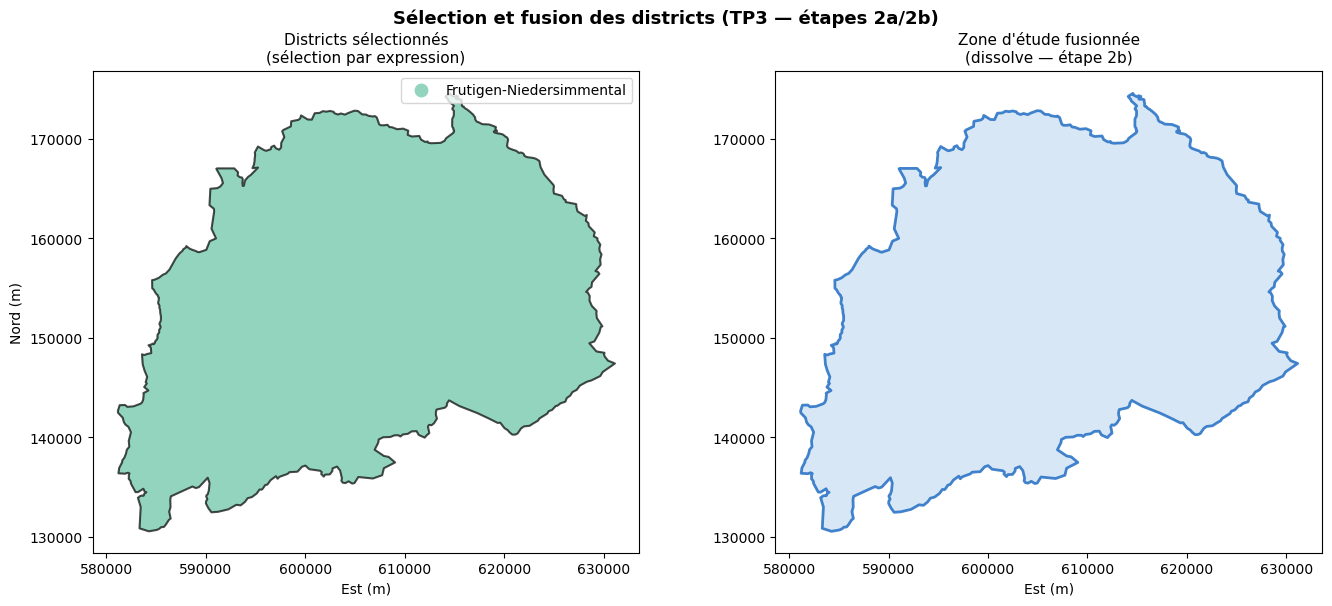

In [55]:
# -------------------------------------------------------
# 2a — Sélection par expression (= filtre SQL dans QGIS)
# -------------------------------------------------------
study_districts = districts[
    districts['NAME'].str.contains(
        'Frutigen-Niedersimmental|Obersimmental-Saanen',
        case=False, na=False
    )
].copy()

print(f"Districts sélectionnés ({len(study_districts)}) :")
for _, row in study_districts.iterrows():
    print(f"  • {row['NAME']}")

# -------------------------------------------------------
# 2b — Fusionner les entités (= dissolve / Fusionner dans QGIS)
# -------------------------------------------------------
study_area = study_districts.dissolve().reset_index(drop=True)[['geometry']]

print(f"\nZone d'étude fusionnée : 1 polygone")
print(f"  Aire totale  : {study_area.geometry.area.iloc[0] / 1e6:.1f} km²")
print(f"  Périmètre    : {study_area.geometry.length.iloc[0] / 1e3:.1f} km")

# -------------------------------------------------------
# Visualisation
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

study_districts.plot(ax=axes[0], column='NAME', cmap='Set2',
                     edgecolor='black', linewidth=1.5, alpha=0.7, legend=True)
axes[0].set_title('Districts sélectionnés\n(sélection par expression)', fontsize=11)
axes[0].set_xlabel('Est (m)')
axes[0].set_ylabel('Nord (m)')

study_area.plot(ax=axes[1], facecolor='#cfe2f3', edgecolor='#1565c0',
                linewidth=2, alpha=0.8)
axes[1].set_title('Zone d\'étude fusionnée\n(dissolve — étape 2b)', fontsize=11)
axes[1].set_xlabel('Est (m)')

plt.suptitle('Sélection et fusion des districts (TP3 — étapes 2a/2b)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.2 Découpage des couches (étape 2c)

Une fois le périmètre défini, on découpe toutes les couches avec **`gpd.clip()`**,
l'équivalent de l'outil **Couper** (*Clip*) dans QGIS.
Cela garantit que les géotraitements suivants ne portent que sur la zone d'étude.


Découpage des couches à la zone d'étude...

Résultat du découpage :
  Forêt       :    409 entités
  Bâtiments   :   2680 entités
  Routes      :    806 entités
  Communes    :     48 entités


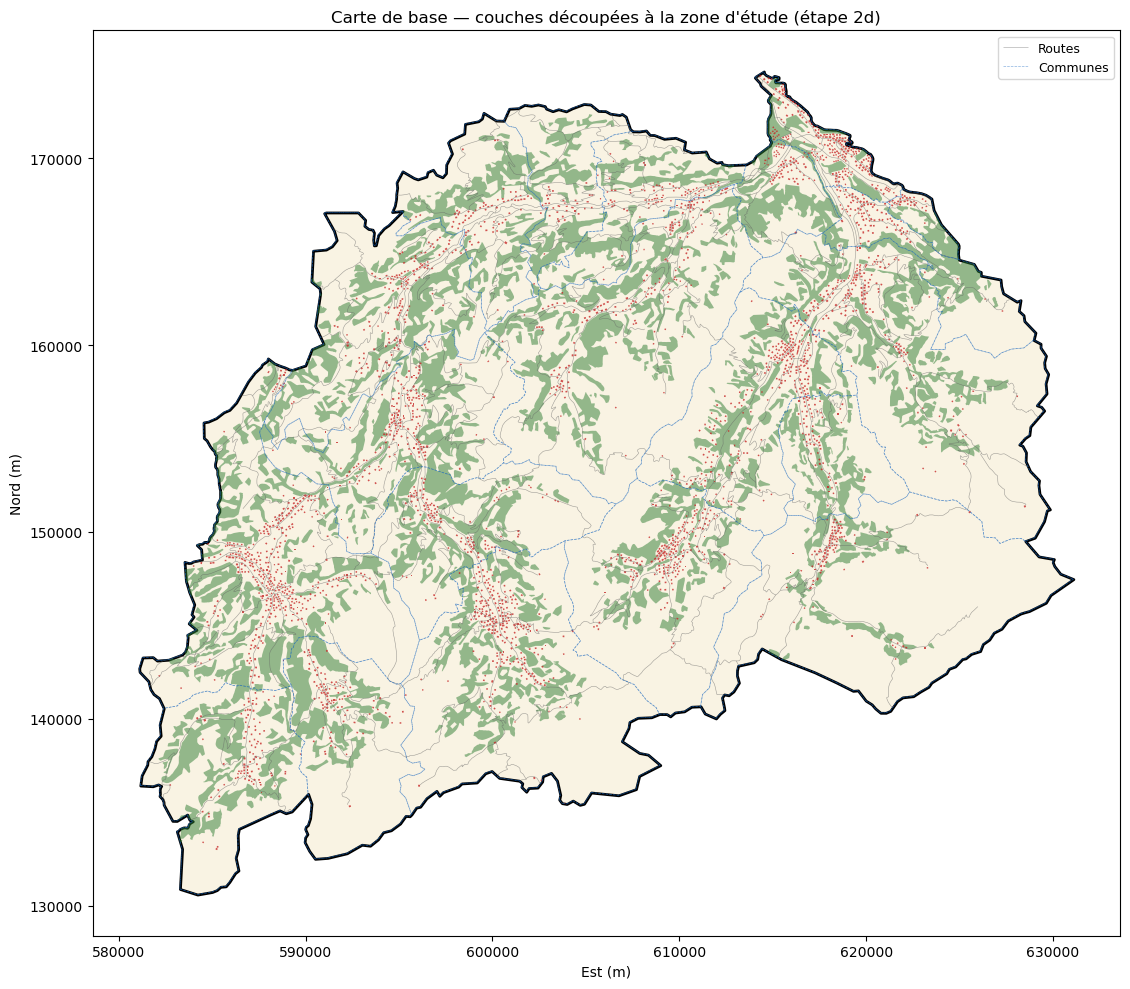

In [56]:
# -------------------------------------------------------
# 2c — Découpage (= outil Clip dans QGIS)
# -------------------------------------------------------
print("Découpage des couches à la zone d'étude...")

foret_clip     = gpd.clip(foret,     study_area).reset_index(drop=True)
buildings_clip = gpd.clip(buildings, study_area).reset_index(drop=True)
roads_clip     = gpd.clip(roads,     study_area).reset_index(drop=True)
communes_clip  = gpd.clip(communes,  study_area).reset_index(drop=True)

print("\nRésultat du découpage :")
for name, gdf in [
    ('Forêt',      foret_clip),
    ('Bâtiments',  buildings_clip),
    ('Routes',     roads_clip),
    ('Communes',   communes_clip),
]:
    print(f"  {name:12s}: {len(gdf):6d} entités")

# -------------------------------------------------------
# Carte de base découpée (étape 2d dans QGIS)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

study_area.plot(ax=ax, facecolor='#f9f3e3', edgecolor='black', linewidth=2, zorder=1)
foret_clip.plot(ax=ax, color='#2e7d32', alpha=0.5, label='Forêt', zorder=2)
buildings_clip.plot(ax=ax, color='#c62828', alpha=0.8, markersize=0.3,
                    label='Bâtiments', zorder=3)
roads_clip.plot(ax=ax, color='#616161', linewidth=0.4, alpha=0.6,
                label='Routes', zorder=4)
communes_clip.plot(ax=ax, facecolor='none', edgecolor='#1565c0',
                   linewidth=0.5, linestyle='--', alpha=0.5,
                   label='Communes', zorder=5)

ax.set_title('Carte de base — couches découpées à la zone d\'étude (étape 2d)', fontsize=12)
ax.set_xlabel('Est (m)')
ax.set_ylabel('Nord (m)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


---
## Partie 2 — Zones tampons (Buffer)

Les zones tampons permettent de définir des zones de proximité autour d'entités.
Dans QGIS, nous avons utilisé l'outil **Zone tampon** pour :

1. **Zone Densément Bâtie (ZDB)** — buffer `+75 m` sur les bâtiments (regroupé),
   puis buffer `−75 m` pour conserver uniquement les zones densément bâties
2. **Emprise des routes** — buffer de `6 m` (= moitié de la largeur de 12 m)

| Outil QGIS | Équivalent Python |
|---|---|
| Zone tampon (Buffer) | `.buffer(distance)` sur `geometry` |
| Regrouper le résultat | `.unary_union` (fusionne en une seule géométrie) |

### 2.1 ZDB — Zone Densément Bâtie (étape 3a)


Étape 1 : buffer +75 m sur les bâtiments (regroupé)...
Étape 2 : buffer −75 m pour garder uniquement les zones denses (ZDB)...
  ZDB : aire totale = 32.30 km²

Buffer routes (6 m)...
  Routes bufferisées : aire = 15.05 km²


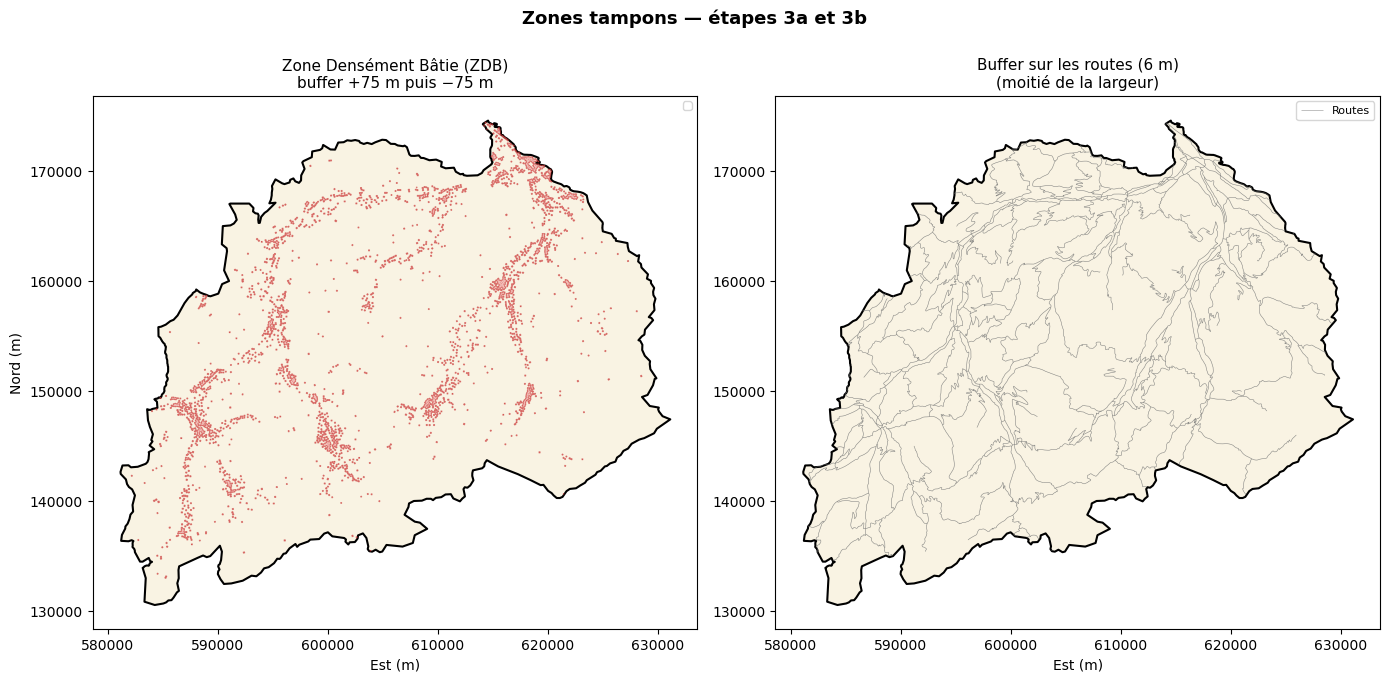

In [57]:
# -------------------------------------------------------
# 3a — Zone Densément Bâtie (ZDB)
#   Étape 1 : buffer +75 m sur les bâtiments, regroupé (unary_union)
#   Étape 2 : buffer −75 m pour éliminer les zones peu denses
# -------------------------------------------------------
print("Étape 1 : buffer +75 m sur les bâtiments (regroupé)...")
buf_pos = buildings_clip.geometry.buffer(75).unary_union   # buffer + dissolve

print("Étape 2 : buffer −75 m pour garder uniquement les zones denses (ZDB)...")
zdb_geom = buf_pos.buffer(-75)
zdb = gpd.GeoDataFrame(geometry=[zdb_geom], crs=CRS_REF)
print(f"  ZDB : aire totale = {zdb_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 3b — Buffer routes (6 m = moitié de la largeur totale de 12 m)
# -------------------------------------------------------
print("\nBuffer routes (6 m)...")
roads_buf_geom = roads_clip.geometry.buffer(6).unary_union
roads_buf = gpd.GeoDataFrame(geometry=[roads_buf_geom], crs=CRS_REF)
print(f"  Routes bufferisées : aire = {roads_buf_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# Visualisation
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

study_area.plot(ax=axes[0], facecolor='#f9f3e3', edgecolor='black', linewidth=1.5)
buildings_clip.plot(ax=axes[0], color='#c62828', alpha=0.5, markersize=0.5,
                    label='Bâtiments')
zdb.plot(ax=axes[0], facecolor='#ef9a9a', edgecolor='#c62828',
         linewidth=0.8, alpha=0.5, label='ZDB (±75 m)')
axes[0].set_title('Zone Densément Bâtie (ZDB)\nbuffer +75 m puis −75 m', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Est (m)')
axes[0].set_ylabel('Nord (m)')

study_area.plot(ax=axes[1], facecolor='#f9f3e3', edgecolor='black', linewidth=1.5)
roads_clip.plot(ax=axes[1], color='#616161', linewidth=0.4, alpha=0.7,
                label='Routes')
roads_buf.plot(ax=axes[1], facecolor='#b0bec5', edgecolor='none',
               alpha=0.6, label='Buffer routes (6 m)')
axes[1].set_title('Buffer sur les routes (6 m)\n(moitié de la largeur)', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Est (m)')

plt.suptitle('Zones tampons — étapes 3a et 3b', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Partie 3 — Superposition (Union, Différence, Intersection)

Ces outils permettent de combiner plusieurs couches pour créer de nouvelles entités.
C'est l'étape centrale du TP pour produire la **WUI** (Wildland-Urban Interface).

| Outil QGIS | Équivalent Python (shapely) |
|---|---|
| Union | `geom_a.union(geom_b)` |
| Différence | `geom_a.difference(geom_b)` |
| Intersection | `geom_a.intersection(geom_b)` |

### 3.1 Zone Urbaine (ZU) = ZDB ∪ routes (étape 4a)
### 3.2 Zone à risque = Buffer(ZU, 80 m) − ZU (étape 4b)
### 3.3 WUI = zone à risque ∩ Forêt (étape 4c)


4a — Union : ZDB ∪ routes bufferisées → Zone Urbaine (ZU)...
  Zone Urbaine (ZU) : aire = 46.66 km²
4b — Buffer 80 m + Différence → zone de risque incendie...
  Zone à risque (bande 80 m hors ZU) : aire = 233.50 km²
4c — Intersection zone risque ∩ Forêt → WUI...
  WUI : aire = 46.21 km²
  WUI représente 15.5 % de la surface forestière


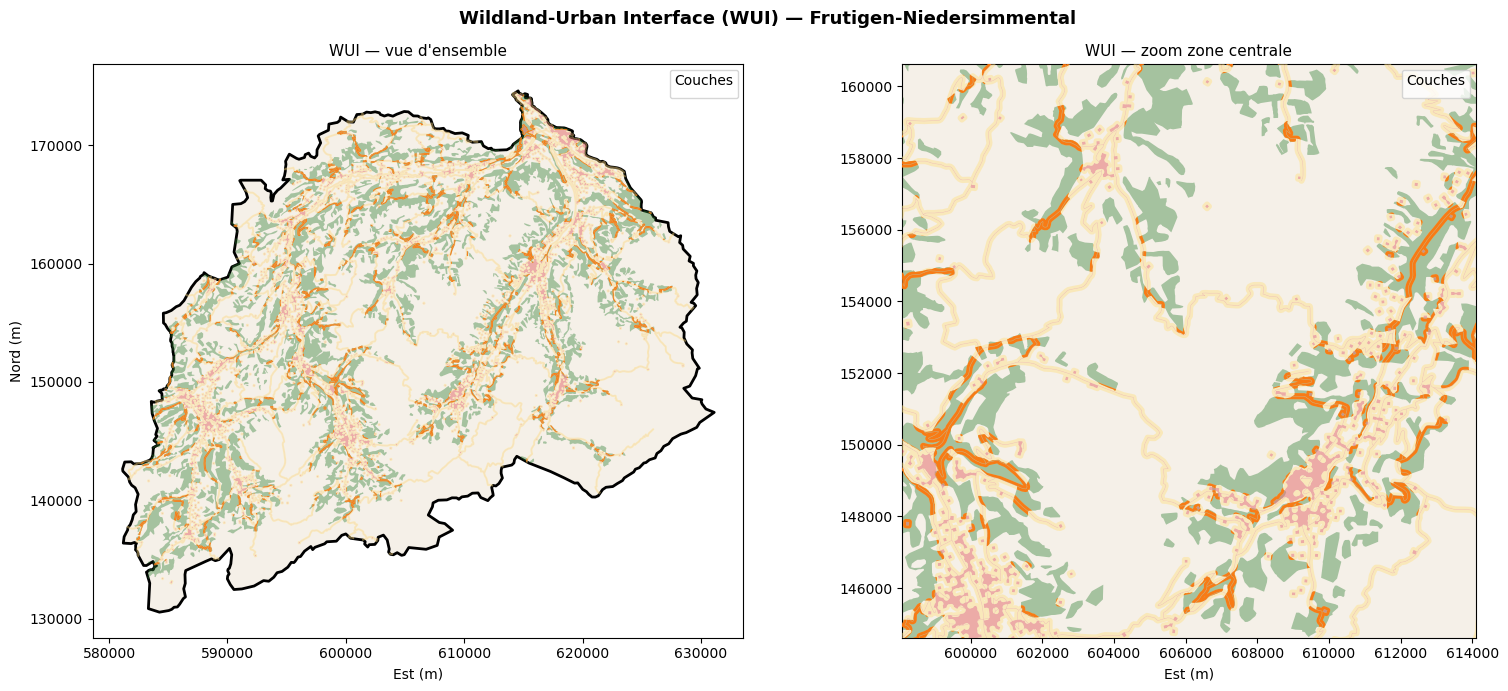

In [58]:
# -------------------------------------------------------
# 4a — Union ZDB ∪ routes bufferisées → Zone Urbaine (ZU)
# -------------------------------------------------------
print("4a — Union : ZDB ∪ routes bufferisées → Zone Urbaine (ZU)...")
zu_geom = zdb_geom.union(roads_buf_geom)
zu = gpd.GeoDataFrame(geometry=[zu_geom], crs=CRS_REF)
print(f"  Zone Urbaine (ZU) : aire = {zu_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 4b — Buffer 80 m autour de ZU + Différence → zone de risque incendie
# -------------------------------------------------------
print("4b — Buffer 80 m + Différence → zone de risque incendie...")
zu_buf_80 = zu_geom.buffer(80)
zone_risque_geom = zu_buf_80.difference(zu_geom)
zone_risque = gpd.GeoDataFrame(geometry=[zone_risque_geom], crs=CRS_REF)
print(f"  Zone à risque (bande 80 m hors ZU) : aire = {zone_risque_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 4c — Intersection zone risque ∩ Forêt → WUI
# -------------------------------------------------------
print("4c — Intersection zone risque ∩ Forêt → WUI...")
foret_union = foret_clip.geometry.unary_union
wui_geom = zone_risque_geom.intersection(foret_union)
wui = gpd.GeoDataFrame(geometry=[wui_geom], crs=CRS_REF)
print(f"  WUI : aire = {wui_geom.area / 1e6:.2f} km²")
print(f"  WUI représente {wui_geom.area / foret_union.area * 100:.1f} % de la surface forestière")

# -------------------------------------------------------
# Carte finale — WUI (vue d'ensemble + zoom)
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax in axes:
    study_area.plot(ax=ax, facecolor='#f5f0e8', edgecolor='black', linewidth=2, zorder=1)
    foret_clip.plot(ax=ax, color='#2e7d32', alpha=0.4, label='Forêt', zorder=2)
    zu.plot(ax=ax, facecolor='#e57373', edgecolor='none', alpha=0.55,
            label='Zone Urbaine (ZU)', zorder=3)
    zone_risque.plot(ax=ax, facecolor='#ffe082', edgecolor='none', alpha=0.45,
                     label='Zone à risque (80 m)', zorder=4)
    wui.plot(ax=ax, facecolor='#ff6d00', edgecolor='none', alpha=0.85,
             label='WUI', zorder=5)

axes[0].set_title('WUI — vue d\'ensemble', fontsize=11)
axes[0].set_xlabel('Est (m)'); axes[0].set_ylabel('Nord (m)')
axes[0].legend(loc='upper right', fontsize=8, title='Couches')

# Zoom au centre pour mieux voir le WUI
b = study_area.total_bounds
cx, cy = (b[0]+b[2])/2, (b[1]+b[3])/2
zoom = 8000
axes[1].set_xlim(cx - zoom, cx + zoom)
axes[1].set_ylim(cy - zoom, cy + zoom)
axes[1].set_title('WUI — zoom zone centrale', fontsize=11)
axes[1].set_xlabel('Est (m)')
axes[1].legend(loc='upper right', fontsize=8, title='Couches')

plt.suptitle('Wildland-Urban Interface (WUI) — Frutigen-Niedersimmental',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Partie 4 — Du vecteur au raster

Pour passer aux régressions (Partie 5), nous devons convertir nos couches
vectorielles en **grilles raster** — comme si on exportait en GeoTIFF depuis QGIS.

L'opération clé est la **rasterisation** : on projette chaque géométrie vectorielle
sur une grille régulière de pixels. Chaque pixel reçoit la valeur de la classe
qui le couvre (forêt, urbain, WUI…).

| Couche vectorielle | Classe raster |
|---|---|
| Hors zone / prairie | 0 — Autre |
| Zone Urbaine (ZU) | 1 — Zone urbaine |
| Forêt (hors WUI) | 2 — Forêt |
| WUI | 3 — WUI |


Grille raster : 200 × 200 pixels
  Emprise      : X [581097 — 631085], Y [130593 — 174637]
  Résolution   : 250 m × 220 m par pixel

Distribution des classes (données vectorielles réelles) :
  Classe 0 (Autre          ) :  33876 pixels  (84.7 %)
  Classe 1 (Zone urbaine   ) :    821 pixels  (2.1 %)
  Classe 2 (Forêt          ) :   4440 pixels  (11.1 %)
  Classe 3 (WUI            ) :    863 pixels  (2.2 %)

Distance à ZU    : min=0 m, max=15073 m
Distance à forêt : min=0 m, max=16639 m


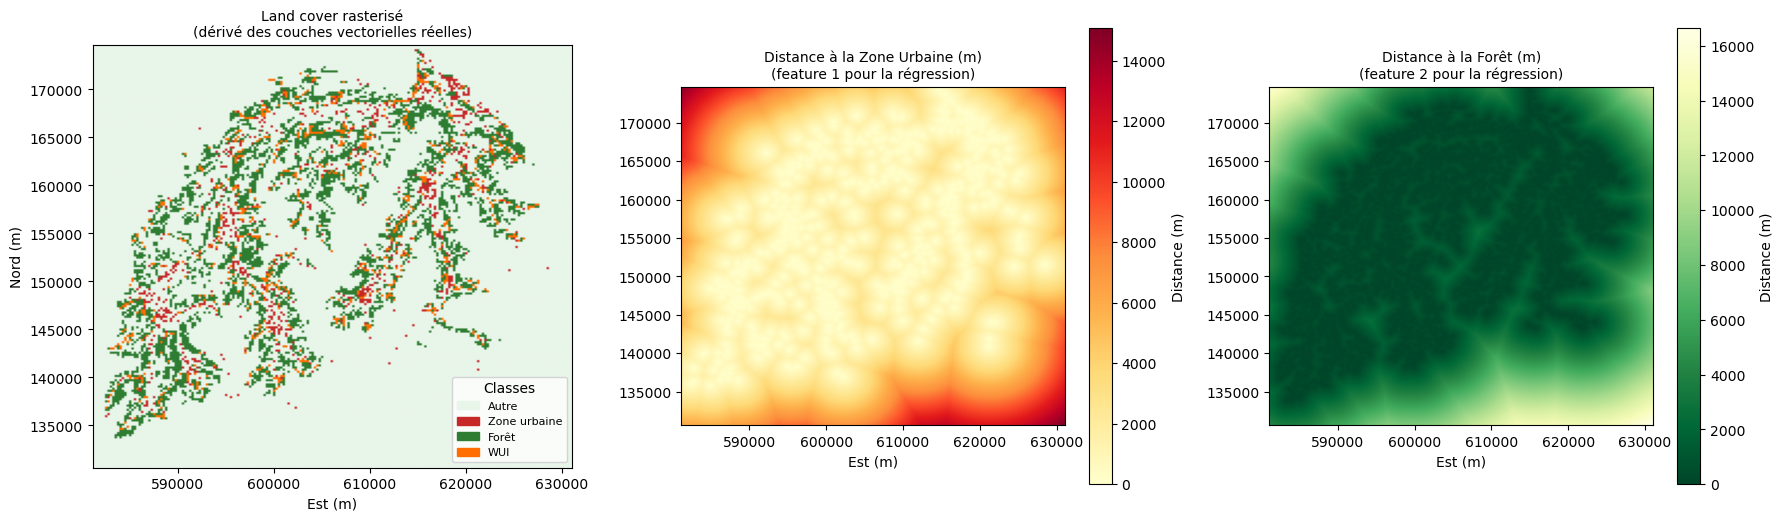

In [59]:
# -------------------------------------------------------
# Paramètres de la grille raster (alignée sur la zone d'étude réelle)
# -------------------------------------------------------
b = study_area.total_bounds          # [xmin, ymin, xmax, ymax]
XMIN, YMIN, XMAX, YMAX = int(b[0]), int(b[1]), int(b[2]), int(b[3])
ROWS, COLS = 200, 200
n_pixels   = ROWS * COLS
extent     = [XMIN, XMAX, YMIN, YMAX]   # pour matplotlib imshow
transform  = from_bounds(XMIN, YMIN, XMAX, YMAX, COLS, ROWS)

px_size_x  = (XMAX - XMIN) / COLS   # résolution en mètres
px_size_y  = (YMAX - YMIN) / ROWS

print(f"Grille raster : {ROWS} × {COLS} pixels")
print(f"  Emprise      : X [{XMIN} — {XMAX}], Y [{YMIN} — {YMAX}]")
print(f"  Résolution   : {px_size_x:.0f} m × {px_size_y:.0f} m par pixel")

# -------------------------------------------------------
# Rasterisation des couches vectorielles réelles
# -------------------------------------------------------
def rasterize_layer(gdf_or_geom, transform, shape):
    """Convertit un GeoDataFrame ou une géométrie en masque binaire."""
    if hasattr(gdf_or_geom, 'geometry'):
        geoms = list(gdf_or_geom.geometry)
    else:
        geoms = [gdf_or_geom]
    geoms = [g for g in geoms if g is not None and not g.is_empty]
    if not geoms:
        return np.zeros(shape, dtype=np.uint8)
    return rasterize(
        [(g, 1) for g in geoms],
        out_shape=shape, transform=transform,
        fill=0, dtype=np.uint8,
    )

mask_foret = rasterize_layer(foret_clip, transform, (ROWS, COLS))
mask_zu    = rasterize_layer(zu,         transform, (ROWS, COLS))
mask_wui   = rasterize_layer(wui,        transform, (ROWS, COLS))

# Construction du raster de classes (priorité : WUI > ZU > Forêt > Autre)
CLASSES      = {0: 'Autre', 1: 'Zone urbaine', 2: 'Forêt', 3: 'WUI'}
CLASS_COLORS = ['#e8f5e9', '#c62828', '#2e7d32', '#ff6d00']

gt = np.zeros((ROWS, COLS), dtype=np.uint8)
gt[mask_foret == 1] = 2
gt[mask_zu    == 1] = 1
gt[mask_wui   == 1] = 3

print("\nDistribution des classes (données vectorielles réelles) :")
for cls, nom in CLASSES.items():
    n = (gt == cls).sum()
    print(f"  Classe {cls} ({nom:15s}) : {n:6d} pixels  ({100*n/n_pixels:.1f} %)")

# -------------------------------------------------------
# Rasters de distance — entièrement dérivés des masques réels
#   distance_transform_edt : distance euclidienne au pixel "vrai" le plus proche
#   on la convertit en mètres en multipliant par la résolution
# -------------------------------------------------------
dist_zu_px    = distance_transform_edt(mask_zu    == 0)   # distance en pixels vers ZU
dist_foret_px = distance_transform_edt(mask_foret == 0)   # distance en pixels vers forêt

dist_zu_m     = dist_zu_px    * px_size_x   # en mètres
dist_foret_m  = dist_foret_px * px_size_x

print(f"\nDistance à ZU    : min={dist_zu_m.min():.0f} m, max={dist_zu_m.max():.0f} m")
print(f"Distance à forêt : min={dist_foret_m.min():.0f} m, max={dist_foret_m.max():.0f} m")

# -------------------------------------------------------
# Visualisation : land cover + distances
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cmap_gt = mcolors.ListedColormap(CLASS_COLORS)
norm_gt = mcolors.BoundaryNorm([0, 1, 2, 3, 4], cmap_gt.N)

axes[0].imshow(gt, cmap=cmap_gt, norm=norm_gt, extent=extent, origin='upper')
patches = [Patch(color=CLASS_COLORS[i], label=CLASSES[i]) for i in range(4)]
axes[0].legend(handles=patches, loc='lower right', fontsize=8, title='Classes')
axes[0].set_title('Land cover rasterisé\n(dérivé des couches vectorielles réelles)', fontsize=10)
axes[0].set_xlabel('Est (m)'); axes[0].set_ylabel('Nord (m)')

im1 = axes[1].imshow(dist_zu_m, cmap='YlOrRd', extent=extent, origin='upper')
plt.colorbar(im1, ax=axes[1], label='Distance (m)', shrink=0.8)
axes[1].set_title('Distance à la Zone Urbaine (m)\n(feature 1 pour la régression)', fontsize=10)
axes[1].set_xlabel('Est (m)')

im2 = axes[2].imshow(dist_foret_m, cmap='YlGn_r', extent=extent, origin='upper')
plt.colorbar(im2, ax=axes[2], label='Distance (m)', shrink=0.8)
axes[2].set_title('Distance à la Forêt (m)\n(feature 2 pour la régression)', fontsize=10)
axes[2].set_xlabel('Est (m)')

plt.tight_layout()
plt.show()


### 4.1 Analyse spatiale — profil de distance par classe

Les deux rasters de distance permettent d'analyser la **structure spatiale** des classes.
Ce n'est pas du machine learning — c'est simplement lire ce que la géométrie implique :

| Classe | dist_zu_m attendu | dist_foret_m attendu |
|---|---|---|
| Zone urbaine | ≈ 0 (elle *est* la ZU) | élevé |
| Forêt | élevé | ≈ 0 (elle *est* la forêt) |
| **WUI** | faible (proche ZU) | ≈ 0 (dans la forêt) |
| Autre | élevé | élevé |


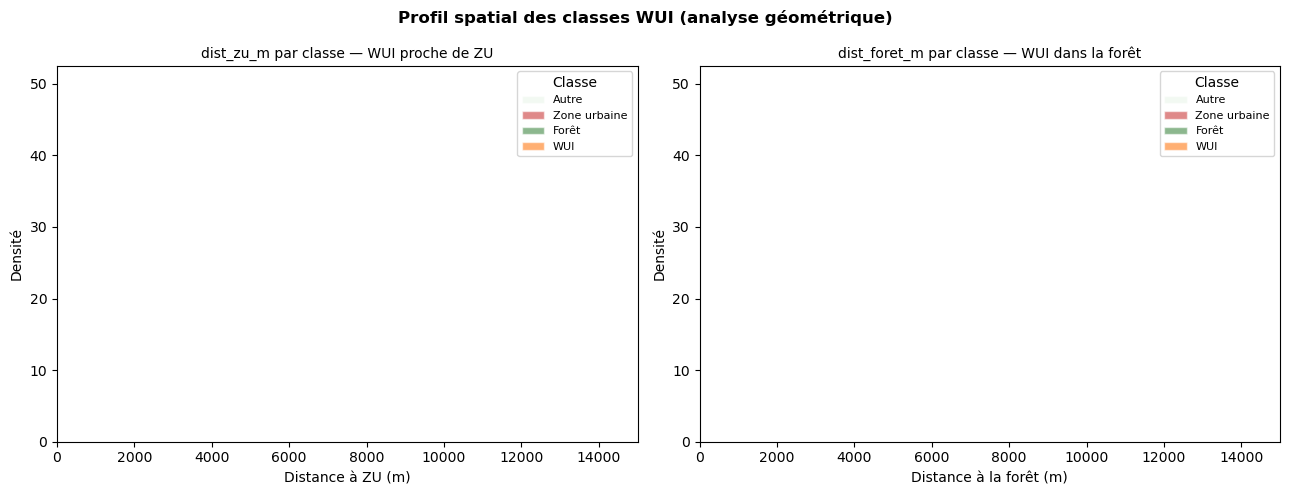

Distance moyenne à ZU et à la forêt par classe :
  Classe             dist_zu_m (moy)   dist_foret_m (moy)
  Autre                      3325 m               3241 m
  Zone urbaine                  0 m                451 m
  Forêt                       927 m                  0 m
  WUI                         745 m                  0 m


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, feat_name in [
    (axes[0], dist_zu_m,    'Distance à ZU (m)'),
    (axes[1], dist_foret_m, 'Distance à la forêt (m)'),
]:
    for cls, nom in CLASSES.items():
        vals = feat[gt == cls]
        ax.hist(vals, bins=50, color=CLASS_COLORS[cls], alpha=0.55,
                edgecolor='white', label=nom, density=True)
    ax.set_xlabel(feat_name)
    ax.set_ylabel('Densité')
    ax.set_xlim(0, 15000)
    ax.legend(fontsize=8, title='Classe')

axes[0].set_title('dist_zu_m par classe — WUI proche de ZU', fontsize=10)
axes[1].set_title('dist_foret_m par classe — WUI dans la forêt', fontsize=10)

plt.suptitle('Profil spatial des classes WUI (analyse géométrique)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Distance moyenne à ZU et à la forêt par classe :")
print(f"  {'Classe':<15} {'dist_zu_m (moy)':>18} {'dist_foret_m (moy)':>20}")
for cls, nom in CLASSES.items():
    print(f"  {nom:<15} {dist_zu_m[gt==cls].mean():>15.0f} m  {dist_foret_m[gt==cls].mean():>17.0f} m")


---
## Partie 5 — Régressions avec scikit-learn

### 5.1 Principe

On travaille à l'échelle de la **commune** pour éviter tout problème de circularité :
les features proviennent de couches différentes du label.

| Modèle | Features | Label | Source des données |
|---|---|---|---|
| Régression logistique | bâtiments/km², routes/km² | densité pop. (haute/basse) | Buildings + Roads → Communes |
| Régression linéaire | bâtiments par commune | population | Buildings → Communes |

> **Pourquoi les distances (dist_zu, dist_foret) seraient-elles du data leakage ?**
> Ces distances sont calculées directement depuis les masques `mask_zu` et `mask_foret`
> qui définissent `gt`. Prédire la classe à partir de la distance à la classe, c'est
> simplement ré-encoder le label — aucun apprentissage réel.


### 5.2 Agrégation spatiale par commune

On calcule, pour chaque commune, deux features par **jointure spatiale** :

- **`bld_per_km2`** : nombre de bâtiments par km² (couche *Buildings*)
- **`road_km_per_km2`** : longueur de routes par km² (couche *Roads*)

Le label est **`high_density`** (1/0) : densité de population au-dessus ou en dessous
de la médiane des communes de la zone d'étude.

Ces trois informations proviennent de **trois couches indépendantes** du geopackage.


In [63]:
# -------------------------------------------------------
# Table de base : communes avec population et aire
# -------------------------------------------------------
comm_data = communes_clip[['NAME', 'EINWOHNERZ', 'GEM_FLAECH', 'geometry']].copy()
comm_data = comm_data[comm_data['EINWOHNERZ'] > 0].reset_index(drop=True)
comm_data['aire_km2'] = comm_data['GEM_FLAECH'] / 1e6

# -------------------------------------------------------
# Feature 1 : densité de bâtiments (Buildings → Communes)
#   Jointure spatiale par centroïde de bâtiment
# -------------------------------------------------------
bld_centroid = buildings_clip[['geometry']].copy()
bld_centroid['geometry'] = buildings_clip.geometry.centroid

bld_join = gpd.sjoin(bld_centroid, comm_data[['geometry']],
                     how='left', predicate='within')
comm_data['n_buildings'] = (bld_join.groupby('index_right').size()
                             .reindex(comm_data.index).fillna(0).astype(int))
comm_data['bld_per_km2'] = comm_data['n_buildings'] / comm_data['aire_km2'].clip(lower=0.01)

# -------------------------------------------------------
# Feature 2 : densité routière (Roads → Communes)
#   Jointure spatiale par centroïde de tronçon
# -------------------------------------------------------
road_centroid = roads_clip[['geometry']].copy()
road_centroid['length_m'] = roads_clip.geometry.length
road_centroid['geometry'] = roads_clip.geometry.centroid

road_join = gpd.sjoin(road_centroid, comm_data[['geometry']],
                      how='left', predicate='within')
comm_data['road_km'] = (road_join.groupby('index_right')['length_m'].sum()
                         .reindex(comm_data.index).fillna(0) / 1000)
comm_data['road_km_per_km2'] = comm_data['road_km'] / comm_data['aire_km2'].clip(lower=0.01)

# -------------------------------------------------------
# Label : densité de population haute (1) ou basse (0)
# -------------------------------------------------------
comm_data['pop_density'] = comm_data['EINWOHNERZ'] / comm_data['aire_km2']
median_density = comm_data['pop_density'].median()
comm_data['high_density'] = (comm_data['pop_density'] > median_density).astype(int)

print(f"Communes : {len(comm_data)}")
print(f"  Densité pop. médiane : {median_density:.1f} hab./km²")
print(f"  Classe 0 (faible densité) : {(comm_data['high_density']==0).sum()} communes")
print(f"  Classe 1 (forte densité)  : {(comm_data['high_density']==1).sum()} communes")
print()
print(comm_data[['NAME','aire_km2','n_buildings','bld_per_km2',
                  'road_km','road_km_per_km2','pop_density','high_density']
               ].sort_values('pop_density', ascending=False).head(8).to_string(index=False))


Communes : 47
  Densité pop. médiane : 283944.2 hab./km²
  Classe 0 (faible densité) : 24 communes
  Classe 1 (forte densité)  : 23 communes

         NAME  aire_km2  n_buildings  bld_per_km2   road_km  road_km_per_km2  pop_density  high_density
         Thun  0.002157            0          0.0  0.000000         0.000000 2.007557e+07             1
        Spiez  0.001672          208      20800.0 38.628936      3862.893629 7.508971e+06             1
    Krattigen  0.000600           29       2900.0  7.313121       731.312055 1.843333e+06             1
Crans-Montana  0.005966            0          0.0  0.000000         0.000000 1.832216e+06             1
  Zwieselberg  0.000246            0          0.0  0.000000         0.000000 1.256098e+06             1
       Wimmis  0.002235           64       6400.0 26.146075      2614.607513 1.087248e+06             1
      Savièse  0.007098            0          0.0  0.000000         0.000000 1.021274e+06             1
    Leissigen  0.001038   

In [64]:
# -------------------------------------------------------
# Features et label
# -------------------------------------------------------
feature_names = ['bld_per_km2', 'road_km_per_km2']

X = comm_data[feature_names].values   # shape : (n_communes, 2)
y = comm_data['high_density'].values  # shape : (n_communes,)

# Train / test split stratifié (garder la proportion 0/1 dans les deux jeux)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entraînement : {len(X_train)} communes")
print(f"Test         : {len(X_test)} communes")

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nFeatures (entraînement, après normalisation) :")
print(f"  Moyennes  : {X_train_sc.mean(axis=0).round(3)}")   # ≈ 0
print(f"  Écart-types : {X_train_sc.std(axis=0).round(3)}")  # ≈ 1


Entraînement : 37 communes
Test         : 10 communes

Features (entraînement, après normalisation) :
  Moyennes  : [-0.  0.]
  Écart-types : [1. 1.]


### 5.3 Entraînement — régression logistique


In [65]:
clf = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
clf.fit(X_train_sc, y_train)

train_acc = clf.score(X_train_sc, y_train)
test_acc  = clf.score(X_test_sc,  y_test)

print(f"Entraînement terminé")
print(f"  Précision entraînement : {train_acc:.2f}  ({train_acc*100:.1f} %)")
print(f"  Précision test         : {test_acc:.2f}  ({test_acc*100:.1f} %)")


Entraînement terminé
  Précision entraînement : 0.68  (67.6 %)
  Précision test         : 0.30  (30.0 %)


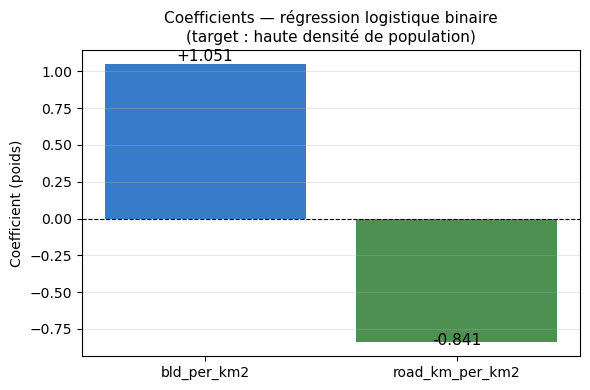


Interprétation :
  bld_per_km2          : +1.051  → ↑ haute densité
  road_km_per_km2      : -0.841  → ↓ faible densité


In [66]:
# clf.coef_ : shape (1, n_features) pour classification binaire
fig, ax = plt.subplots(figsize=(6, 4))
x_pos = np.arange(len(feature_names))
ax.bar(x_pos, clf.coef_[0], color=['#1565c0', '#2e7d32'], alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Coefficients — régression logistique binaire\n(target : haute densité de population)', fontsize=11)
ax.set_ylabel('Coefficient (poids)')
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(clf.coef_[0]):
    ax.text(i, v + 0.02 * np.sign(v), f'{v:+.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nInterprétation :")
for name, coef in zip(feature_names, clf.coef_[0]):
    direction = "↑ haute densité" if coef > 0 else "↓ faible densité"
    print(f"  {name:20s} : {coef:+.3f}  → {direction}")


### 5.4 Évaluation — rapport de classification et matrice de confusion

Avec 47 communes et un jeu de test de ~10 communes, les résultats seront
indicatifs plutôt que statistiquement robustes. L'objectif est d'illustrer
la démarche, pas de construire un modèle de production.


=== Rapport de classification ===
                precision    recall  f1-score   support

Faible densité       0.38      0.60      0.46         5
 Forte densité       0.00      0.00      0.00         5

      accuracy                           0.30        10
     macro avg       0.19      0.30      0.23        10
  weighted avg       0.19      0.30      0.23        10



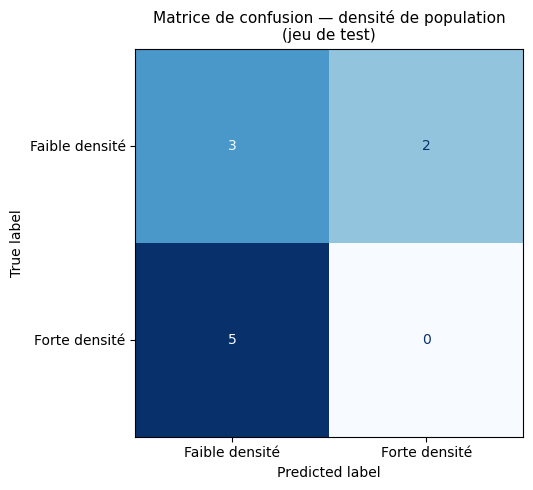

In [67]:
y_pred = clf.predict(X_test_sc)
label_names = ['Faible densité', 'Forte densité']

print("=== Rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de confusion — densité de population\n(jeu de test)', fontsize=11)
plt.tight_layout()
plt.show()


### 5.5 Carte — prédictions sur toutes les communes

On applique le modèle à toutes les communes (entraînement + test)
et on compare la densité réelle à la densité prédite sous forme de **carte choroplèthe**.


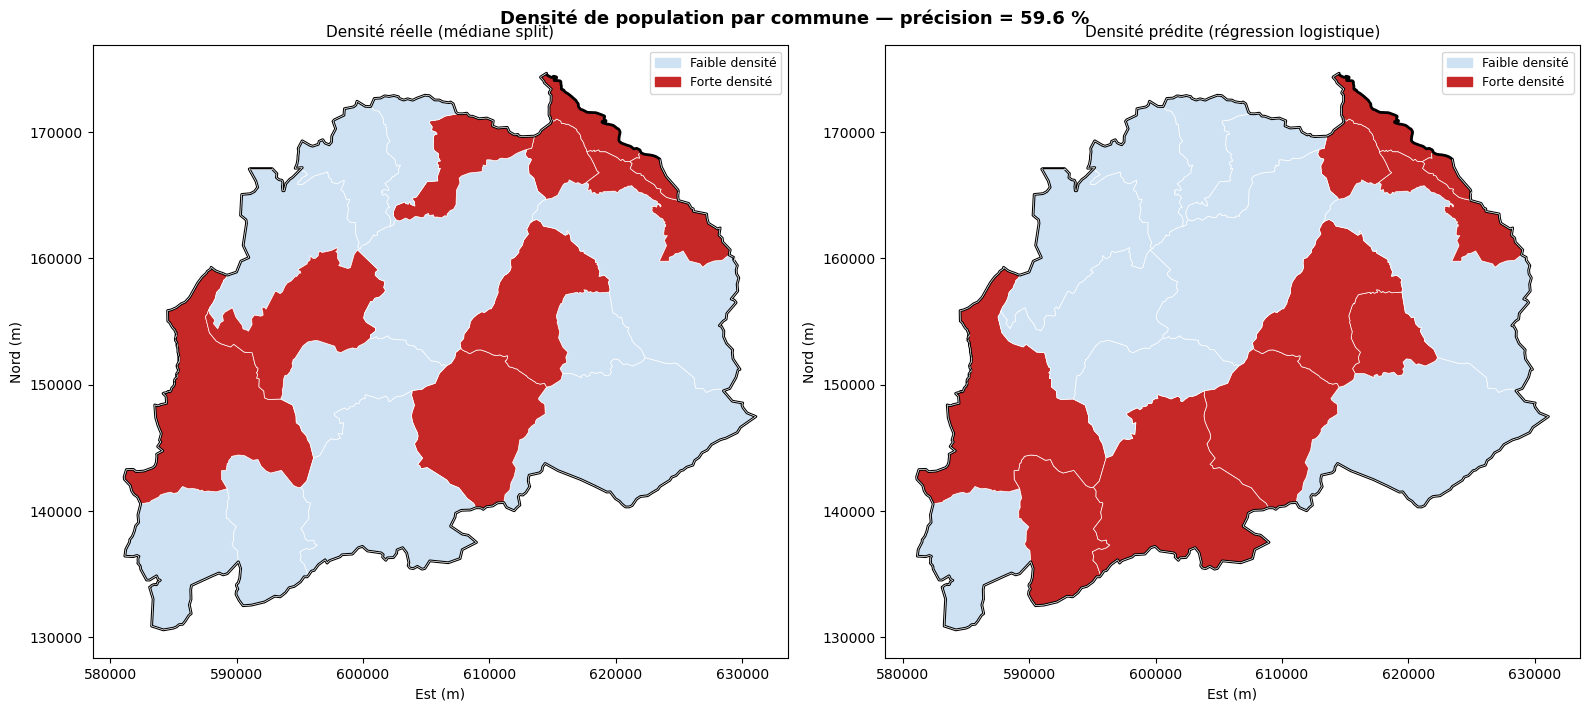

In [68]:
X_all_sc = scaler.transform(X)
comm_data['predicted'] = clf.predict(X_all_sc)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cmap_bin  = mcolors.ListedColormap(['#cfe2f3', '#c62828'])
norm_bin  = mcolors.BoundaryNorm([0, 0.5, 1], 2)
label_map = {0: 'Faible densité', 1: 'Forte densité'}

for ax, col, title in [
    (axes[0], 'high_density', 'Densité réelle (médiane split)'),
    (axes[1], 'predicted',    'Densité prédite (régression logistique)'),
]:
    comm_data.plot(column=col, ax=ax, cmap=cmap_bin, vmin=0, vmax=1,
                   edgecolor='white', linewidth=0.5)
    study_area.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2)
    patches = [Patch(color=cmap_bin(v), label=label_map[v]) for v in [0, 1]]
    ax.legend(handles=patches, loc='upper right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Est (m)'); ax.set_ylabel('Nord (m)')

plt.suptitle(f'Densité de population par commune — précision = {clf.score(X_all_sc, y)*100:.1f} %',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.6 Régression linéaire — population ~ nombre de bâtiments

`LinearRegression` prédit la **population** d'une commune à partir de son
**nombre de bâtiments** — deux attributs de couches distinctes, sans aucune circularité.


Régression linéaire — population ~ nombre de bâtiments
  Coefficient : 256.8  (normalisé)
  Intercept   : 3522 hab.
  MAE         : 2162 habitants
  R²          : -0.511


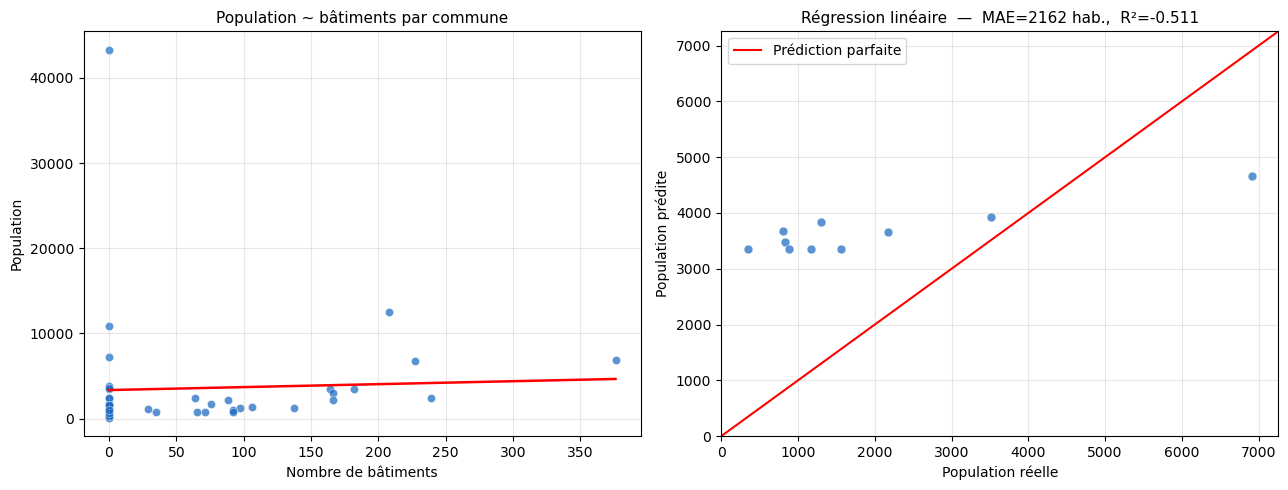

In [69]:
X_reg = comm_data[['n_buildings']].values   # feature : nombre de bâtiments (Buildings)
y_reg = comm_data['EINWOHNERZ'].values      # label   : population (Communes)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

regr = LinearRegression()
regr.fit(X_reg_train_sc, y_reg_train)

y_reg_pred = regr.predict(X_reg_test_sc)
mae = mean_absolute_error(y_reg_test, y_reg_pred)
r2  = r2_score(y_reg_test, y_reg_pred)

print(f"Régression linéaire — population ~ nombre de bâtiments")
print(f"  Coefficient : {regr.coef_[0]:.1f}  (normalisé)")
print(f"  Intercept   : {regr.intercept_:.0f} hab.")
print(f"  MAE         : {mae:.0f} habitants")
print(f"  R²          : {r2:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Nuage brut
axes[0].scatter(comm_data['n_buildings'], comm_data['EINWOHNERZ'],
                s=35, alpha=0.7, color='#1565c0', edgecolor='white', linewidth=0.4)
# Ligne de régression (sur toutes les données)
x_line = np.linspace(comm_data['n_buildings'].min(), comm_data['n_buildings'].max(), 100)
x_line_sc = scaler_reg.transform(x_line.reshape(-1, 1))
axes[0].plot(x_line, regr.predict(x_line_sc), color='red', linewidth=1.8)
axes[0].set_xlabel('Nombre de bâtiments')
axes[0].set_ylabel('Population')
axes[0].set_title('Population ~ bâtiments par commune', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Prédit vs réel (test)
axes[1].scatter(y_reg_test, y_reg_pred, s=40, alpha=0.7,
                color='#1565c0', edgecolor='white', linewidth=0.4)
lim = [0, max(y_reg_test.max(), y_reg_pred.max()) * 1.05]
axes[1].plot(lim, lim, color='red', linewidth=1.5, label='Prédiction parfaite')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('Population réelle')
axes[1].set_ylabel('Population prédite')
axes[1].set_title(f'Régression linéaire  —  MAE={mae:.0f} hab.,  R²={r2:.3f}', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Récapitulatif

### Parties 1–3 — Géotraitement vectoriel

| Opération QGIS | Code Python clé |
|---|---|
| Sélection par expression | `gdf[gdf['col'].str.contains(...)]` |
| Fusionner (dissolve) | `gdf.dissolve()` |
| Couper (Clip) | `gpd.clip(layer, mask)` |
| Zone tampon (Buffer) | `.buffer(dist)` + `.unary_union` |
| Union / Différence / Intersection | `geom_a.union/difference/intersection(geom_b)` |

### Partie 4 — Du vecteur au raster

| Opération | Code clé |
|---|---|
| Rasteriser | `rasterize([(geom, val)], out_shape, transform)` |
| Distance à une classe | `distance_transform_edt(mask == 0) * px_size` |
| Analyse par classe | `feat[gt == cls].mean()` |

### Partie 5 — Régressions sans data leakage

| Étape | Code clé |
|---|---|
| Agrégation spatiale | `gpd.sjoin(centroids, communes)` + `.groupby().size()` |
| Features | bâtiments/km², routes/km² (couches indépendantes du label) |
| Label logistique | `(pop_density > median).astype(int)` |
| Label linéaire | population (couche Communes) |
| Features linéaire | nombre de bâtiments (couche Buildings) |
| Carte résultat | `comm_data.plot(column='predicted')` (choroplèthe) |

> **Règle clé** : une feature ne doit jamais être calculée depuis la même source
> que le label. Ici, buildings (feature) ≠ population (label) ≠ routes (feature).
